<a href="https://colab.research.google.com/github/nenavathgreeshmasreebai/SCT_DS_02/blob/main/SCT_DS_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, os, re, math, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
print('Python', sys.version)
print('pandas', pd.__version__)
print('numpy', np.__version__)

Python 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
pandas 2.2.2
numpy 2.0.2


In [4]:
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print('Shape:', df.shape)
display(df.head())
display(df.tail())
display(df.sample(5, random_state=RANDOM_STATE))
display(df.describe(include='all'))
print('\nInfo:')
print(df.info())

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [6]:
missing = df.isna().sum().to_frame('missing_count')
missing['missing_pct'] = missing['missing_count'] / len(df) * 100.0
missing.sort_values('missing_pct', ascending=False, inplace=True)
display(missing)

,missing_count,missing_pct
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


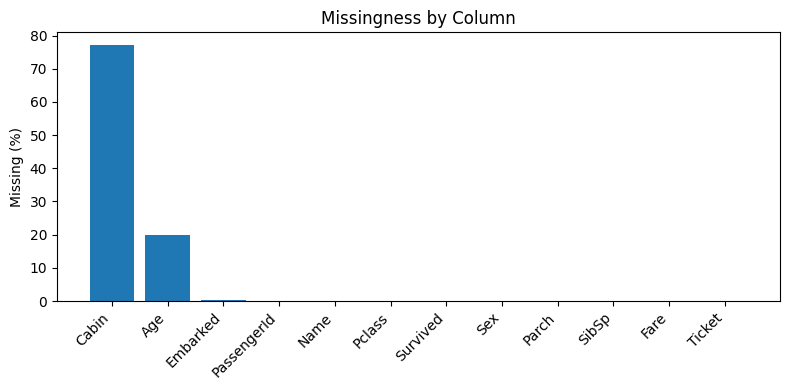

In [7]:
plt.figure(figsize=(8,4))
plt.bar(missing.index, missing['missing_pct'])
plt.ylabel('Missing (%)')
plt.title('Missingness by Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
df_clean = df.copy()

In [9]:
df_clean.columns = [c.strip().lower() for c in df_clean.columns]

In [10]:
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after = df_clean.shape[0]
print(f'Dropped {before - after} duplicate rows')


Dropped 0 duplicate rows


In [11]:
def extract_title(name: str) -> str:
    # Extract title from 'Last, Title. First'
    m = re.search(r',\s*([^\.]+)\.', name)
    if m:
        return m.group(1).strip()
    return 'Unknown'

df_clean['title'] = df_clean['name'].apply(extract_title)

In [12]:
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Royalty', 'Countess': 'Royalty', 'Sir': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty',
    'Jonkheer': 'Royalty', 'the Countess': 'Royalty', 'Capt': 'Officer', 'Col': 'Officer',
    'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer'
}
df_clean['title'] = df_clean['title'].replace(title_map)


if df_clean['embarked'].isna().any():
    embarked_mode = df_clean['embarked'].mode().iloc[0]
    df_clean['embarked'] = df_clean['embarked'].fillna(embarked_mode)


if df_clean['fare'].isna().any():
    df_clean['fare'] = df_clean.groupby('pclass')['fare'].transform(lambda s: s.fillna(s.median()))

if df_clean['age'].isna().any():
    df_clean['age'] = df_clean.groupby(['pclass','sex'])['age'].transform(lambda s: s.fillna(s.median()))

In [13]:
df_clean['familysize'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['isalone'] = (df_clean['familysize'] == 1).astype(int)
df_clean['cabin_known'] = (~df_clean['cabin'].isna()).astype(int)
df_clean['cabindeck'] = df_clean['cabin'].astype(str).str[0].replace({'n':'Unknown'})
df_clean['ticket_prefix'] = df_clean['ticket'].astype(str).str.replace(r'\d', '', regex=True).str.replace('.', '').str.strip()
df_clean['ticket_prefix'] = df_clean['ticket_prefix'].replace('', 'None')
df_clean['ticket_group_size'] = df_clean.groupby('ticket')['ticket'].transform('count')

In [14]:
bins = [0, 12, 18, 25, 35, 50, 120]
labels = ['Child','Teen','Student','YoungAdult','Adult','Senior']
df_clean['age_band'] = pd.cut(df_clean['age'], bins=bins, labels=labels, right=True, include_lowest=True)

df_clean['fare_log'] = np.log1p(df_clean['fare'])
q99 = df_clean['fare'].quantile(0.99)
df_clean['fare_clip'] = df_clean['fare'].clip(upper=q99)


In [15]:
df_clean['sex_bin'] = (df_clean['sex'] == 'male').astype(int)
for col in ['embarked','title','cabindeck','age_band','ticket_prefix']:
    df_clean[col] = df_clean[col].astype('category')
df_clean = pd.get_dummies(df_clean, columns=['embarked','title','cabindeck','age_band','ticket_prefix'], drop_first=True)

print('Cleaned shape:', df_clean.shape)
display(df_clean.head())

clean_path = 'titanic_cleaned.csv'
df_clean.to_csv(clean_path, index=False)
print('Saved cleaned dataset to', os.path.abspath(clean_path))

Cleaned shape: (891, 70)


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,...,ticket_prefix_SOC,ticket_prefix_SOP,ticket_prefix_SOTON/O,ticket_prefix_SOTON/OQ,ticket_prefix_SP,ticket_prefix_STON/O,ticket_prefix_SW/PP,ticket_prefix_W/C,ticket_prefix_WE/P,ticket_prefix_WEP
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,False,False,False,False,False,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,False,False,False,False,False,True,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,False,False,False,False,False,False,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,False,False,False,False,False,False,False,False,False,False


Saved cleaned dataset to /content/titanic_cleaned.csv


In [16]:
def plot_rate(series, target, figsize=(6,4), title='Rate by Category'):
    data = pd.concat([series, target], axis=1)
    grp = data.groupby(series.name)[target.name].mean().sort_values(ascending=False)
    plt.figure(figsize=figsize)
    plt.bar(grp.index.astype(str), grp.values)
    plt.ylabel(f'Mean of {target.name}')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

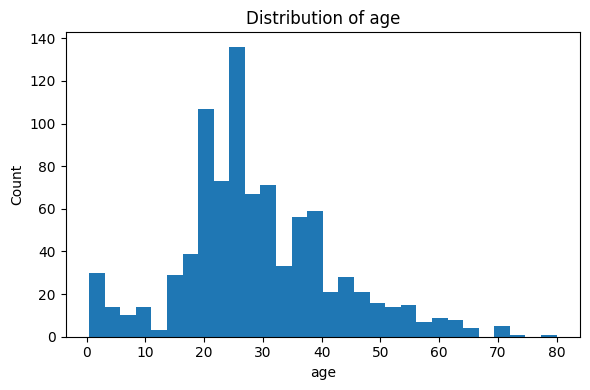

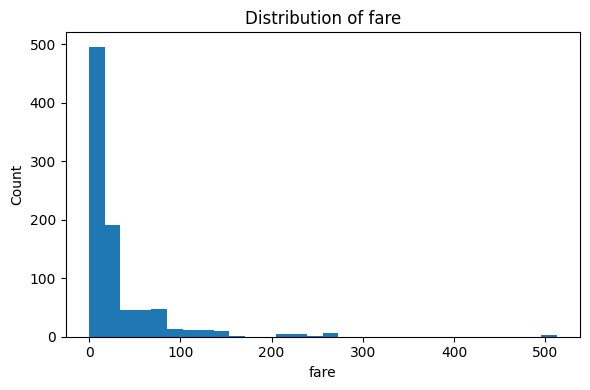

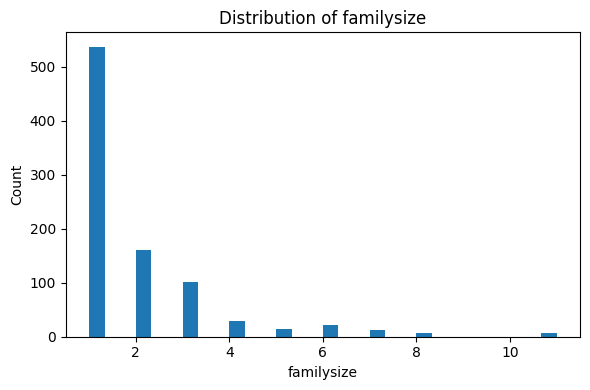

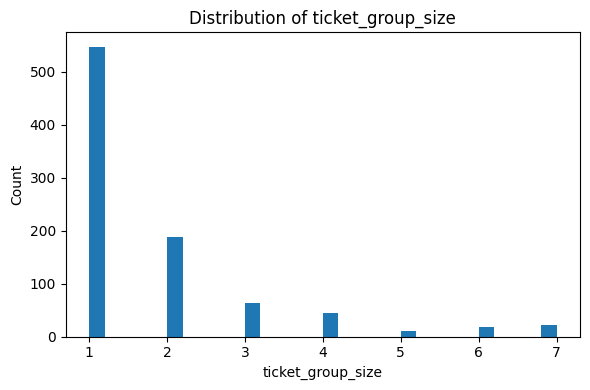

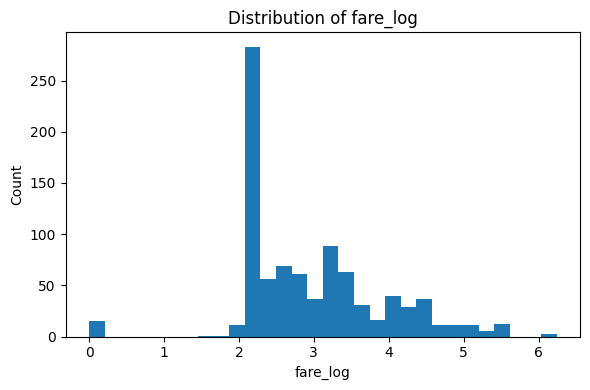

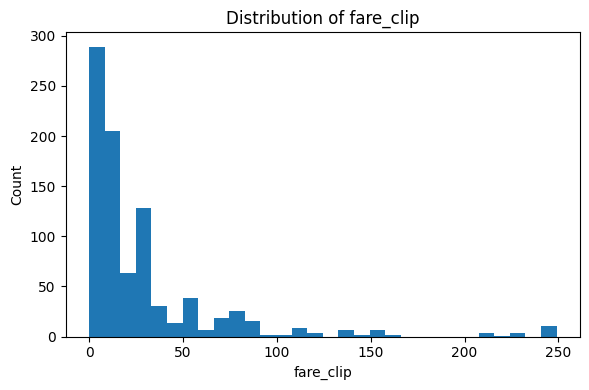

In [17]:
num_cols = ['age','fare','familysize','ticket_group_size','fare_log','fare_clip']
for col in num_cols:
    if col in df_clean.columns:
        plt.figure(figsize=(6,4))
        plt.hist(df_clean[col].dropna(), bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()


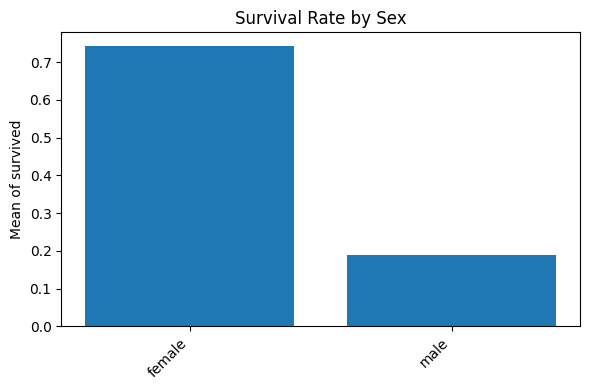

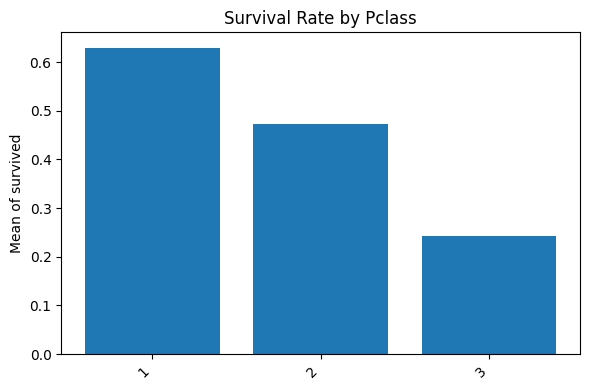

In [18]:
plot_rate(df_clean['sex'], df_clean['survived'], title='Survival Rate by Sex')
plot_rate(df_clean['pclass'], df_clean['survived'], title='Survival Rate by Pclass')

if 'age_band' in [c for c in df.columns] or 'age_band' in df_clean.columns:
    plot_rate(df_clean['age_band_Student'] if 'age_band_Student' in df_clean.columns else df_clean['age_band'],
              df_clean['survived'], title='Survival Rate by Age Band (proxy)')


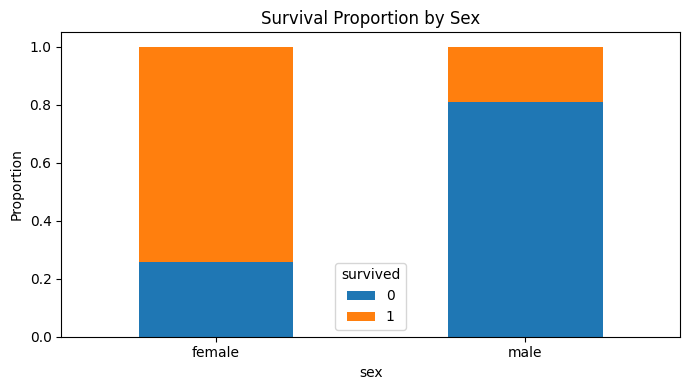

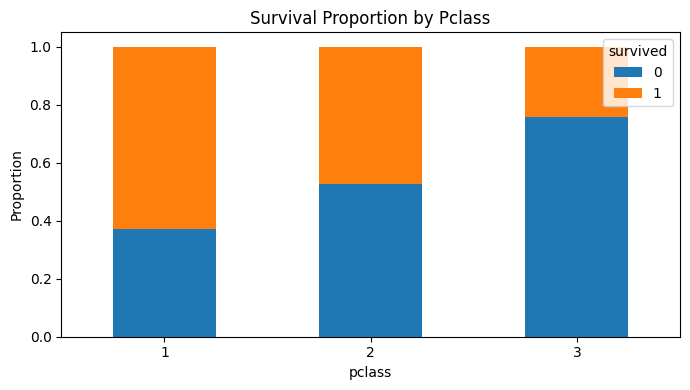

In [19]:
def stacked_bar_crosstab(a, b, title):
    ct = pd.crosstab(a, b, normalize='index')
    ax = ct.plot(kind='bar', stacked=True, figsize=(7,4))
    ax.set_ylabel('Proportion')
    ax.set_title(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

stacked_bar_crosstab(df_clean['sex'], df_clean['survived'], 'Survival Proportion by Sex')
stacked_bar_crosstab(df_clean['pclass'], df_clean['survived'], 'Survival Proportion by Pclass')

/tmp/ipython-input-664959689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df_clean.groupby(['sex','pclass', age_bins])['survived'].mean().unstack(level=2)


age            (-0.001, 12.0]  (12.0, 18.0]  (18.0, 25.0]  (25.0, 35.0]  \
sex    pclass                                                             
female 1             0.000000      1.000000      0.941176      1.000000   
       2             1.000000      1.000000      0.933333      0.925926   
       3             0.478261      0.550000      0.562500      0.500000   
male   1             1.000000      0.500000      0.333333      0.571429   
       2             1.000000      0.000000      0.047619      0.119048   
       3             0.360000      0.076923      0.104651      0.197368   

age            (35.0, 50.0]  (50.0, 120.0]  
sex    pclass                               
female 1           0.960000       1.000000  
       2           0.882353       0.666667  
       3           0.142857       1.000000  
male   1           0.344262       0.192308  
       2           0.055556       0.083333  
       3           0.076923       0.000000

/tmp/ipython-input-664959689.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_clean[df_clean['pclass']==pclass].groupby(age_bins)['survived'].mean()


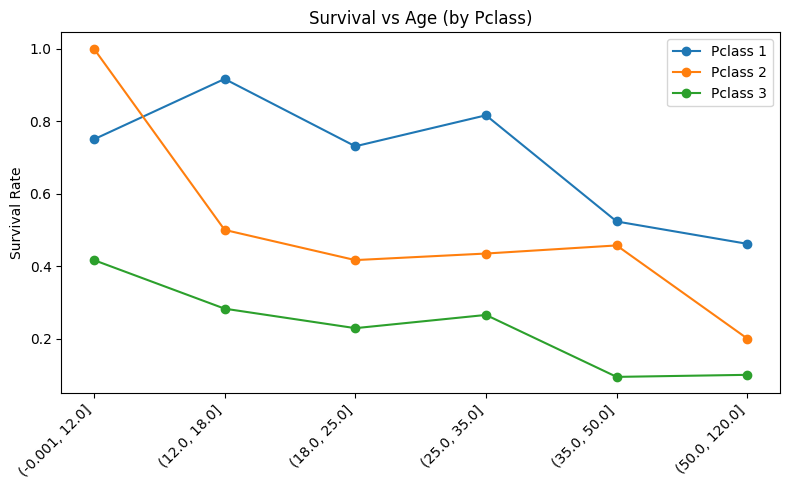

In [20]:
age_bins = pd.cut(df_clean['age'], bins=[0,12,18,25,35,50,120], include_lowest=True)
grp = df_clean.groupby(['sex','pclass', age_bins])['survived'].mean().unstack(level=2)
display(grp)

plt.figure(figsize=(8,5))
for pclass in sorted(df_clean['pclass'].unique()):
    means = df_clean[df_clean['pclass']==pclass].groupby(age_bins)['survived'].mean()
    plt.plot(range(len(means)), means.values, marker='o', label=f'Pclass {pclass}')
plt.xticks(range(len(means)), [str(c) for c in means.index], rotation=45, ha='right')
plt.ylabel('Survival Rate')
plt.title('Survival vs Age (by Pclass)')
plt.legend()
plt.tight_layout()
plt.show()

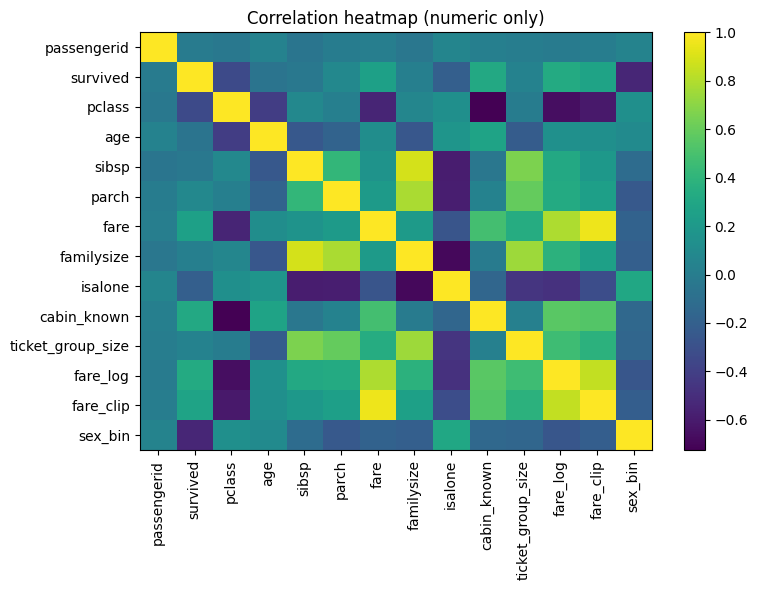

In [21]:
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation heatmap (numeric only)')
plt.tight_layout()
plt.show()


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
target = 'survived'
drop_cols = ['survived','name','ticket','cabin','sex','embarked_S','embarked_C','embarked_Q']
X = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], errors='ignore')
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(classification_report(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179

Confusion Matrix:
 [[94 16]
 [17 52]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,0
title_Mr,-1.588953
fare_log,1.367178
title_Mrs,1.060631
sex_bin,-0.926261
cabin_known,0.647655
ticket_prefix_STON/O,0.513919
cabindeck_E,0.505635
cabindeck_D,0.422308
age_band_Teen,-0.368843
ticket_prefix_W/C,-0.363166


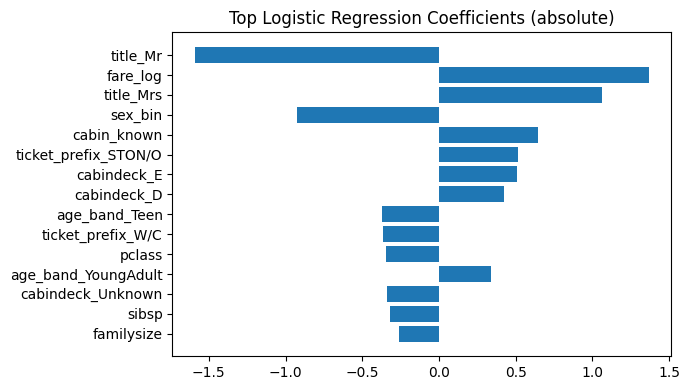

In [24]:
coef = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=lambda s: s.abs(), ascending=False)
display(coef.head(15))

plt.figure(figsize=(7,4))
plt.barh(coef.head(15).index[::-1], coef.head(15).values[::-1])
plt.title('Top Logistic Regression Coefficients (absolute)')
plt.tight_layout()
plt.show()

In [25]:
df_clean.to_csv('titanic_cleaned.csv', index=False)
print('Saved titanic_cleaned.csv to working directory')

Saved titanic_cleaned.csv to working directory
